# HW4: Palmer Penguins — Summary Statistics & Plots
### Gavin Butler

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


In [4]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [5]:
penguins.shape

(344, 8)

344 observations/rows and 8 variables/columns

In [6]:
penguins.dtypes

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object

In [7]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [8]:
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [9]:
penguins['sex'].value_counts()

sex
male      168
female    165
Name: count, dtype: int64

### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [ ]:
# List of columns to check for missing values
cols_to_check = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

# Drop rows with NaN in the specified columns and create a copy
penguins_clean = penguins.dropna(subset=cols_to_check).copy()

# Verify
penguins_clean.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

In [11]:
penguins_clean.shape

(333, 8)

333 rows/observations and 8 columns/variables

### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [12]:
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000,333.000,333.000,333.000,333.000
mean,43.993,17.165,200.967,4207.057,2008.042
std,5.469,1.969,14.016,805.216,0.813
min,32.100,13.100,172.000,2700.000,2007.000
25%,39.500,15.600,190.000,3550.000,2007.000
50%,44.500,17.300,197.000,4050.000,2008.000
75%,48.600,18.700,213.000,4775.000,2009.000
max,59.600,21.500,231.000,6300.000,2009.000


In [13]:
# Group by species, select columns, and calculate statistics
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']
penguins_clean.groupby('species')[numeric_cols].agg(['mean', 'std'])

bill_length_mm        bill_depth_mm        flipper_length_mm         \
                    mean    std          mean    std              mean    std   
species                                                                         
Adelie            38.824  2.663        18.347  1.219           190.103  6.522   
Chinstrap         48.834  3.339        18.421  1.135           195.824  7.132   
Gentoo            47.568  3.106        14.997  0.986           217.235  6.585   

          body_mass_g               year         
                 mean      std      mean    std  
species                                          
Adelie       3706.164  458.620  2008.055  0.812  
Chinstrap    3733.088  384.335  2007.971  0.863  
Gentoo       5092.437  501.476  2008.067  0.789

### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [14]:
# Group by both species and sex, select columns, and aggregate mean and count
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
grouped_summary = penguins_clean.groupby(['species', 'sex'])[features].agg(['mean', 'count'])
grouped_summary

bill_length_mm       bill_depth_mm       flipper_length_mm  \
                           mean count          mean count              mean   
species   sex                                                                 
Adelie    female         37.258    73        17.622    73           187.795   
          male           40.390    73        19.073    73           192.411   
Chinstrap female         46.574    34        17.588    34           191.735   
          male           51.094    34        19.253    34           199.912   
Gentoo    female         45.564    58        14.238    58           212.707   
          male           49.474    61        15.718    61           221.541   

                       body_mass_g        
                 count        mean count  
species   sex                             
Adelie    female    73    3368.836    73  
          male      73    4043.493    73  
Chinstrap female    34    3527.206    34  
          male      34    3938.971    34  
Gentoo    female    58    4679.741    58  
          male      61    5484.836    61

In [ ]:
idx_max = grouped_summary[('body_mass_g', 'mean')].idxmax()
grouped_summary.loc[[idx_max]]

bill_length_mm       bill_depth_mm       flipper_length_mm        \
                       mean count          mean count              mean count   
species sex                                                                     
Gentoo  male         49.474    61        15.718    61           221.541    61   

             body_mass_g        
                    mean count  
species sex                     
Gentoo  male    5484.836    61

### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [16]:
numeric_cols_matrix = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

overall_corr = penguins_clean[numeric_cols_matrix].corr()
overall_corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.229,0.653,0.589
bill_depth_mm,-0.229,1.000,-0.578,-0.472
flipper_length_mm,0.653,-0.578,1.000,0.873
body_mass_g,0.589,-0.472,0.873,1.000


In [17]:
grouped_corr = penguins_clean.groupby('species')[numeric_cols_matrix].corr()
grouped_corr

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.465   
Chinstrap bill_length_mm              1.000          0.654              0.472   
          bill_depth_mm               0.654          1.000              0.580   
          flipper_length_mm           0.472          0.580              1.000   
          body_mass_g                 0.514          0.604              0.642   
Gentoo    bill_length_mm              1.000          0.654              0.664   
          bill_depth_mm               0.654          1.000              0.711   
          flipper_length_mm           0.664          0.711              1.000   
          body_mass_g                 0.667          0.723              0.711   

                             body_mass_g  
species                                   
Adelie    bill_length_mm           0.544  
          bill_depth_mm            0.580  
          flipper_length_mm        0.465  
          body_mass_g              1.000  
Chinstrap bill_length_mm           0.514  
          bill_depth_mm            0.604  
          flipper_length_mm        0.642  
          body_mass_g              1.000  
Gentoo    bill_length_mm           0.667  
          bill_depth_mm            0.723  
          flipper_length_mm        0.711  
          body_mass_g              1.000

A good example of Simpson's Paradox in this dataset is between bill length and bill depth. When combined, the correlation between these 2 across all penguins is $-0.229$. Within subgroups, the correlation between bill length and bill depth is positive for all three species (Adelie: $0.386$, Chinstrap: $0.654$, Gentoo: $0.654$).

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


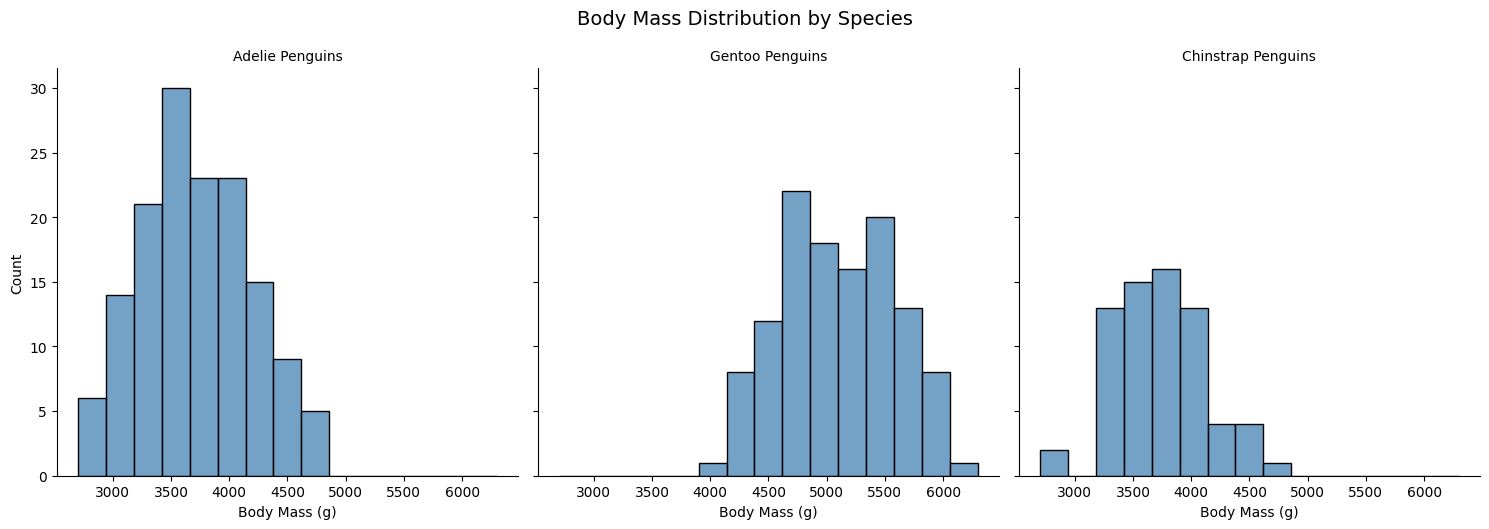

In [18]:
g = sns.displot(
    data=penguins_clean, 
    x='body_mass_g', 
    col='species',     # separate panels for each species
    bins=15,           # consistent binning across all panels
    color='steelblue',
    edgecolor='black'
)

# Set custom overall title, panel titles, and axis labels
g.figure.suptitle("Body Mass Distribution by Species", y=1.05, fontsize=14)
g.set_axis_labels("Body Mass (g)", "Count")
g.set_titles(col_template="{col_name} Penguins")
plt.show()

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

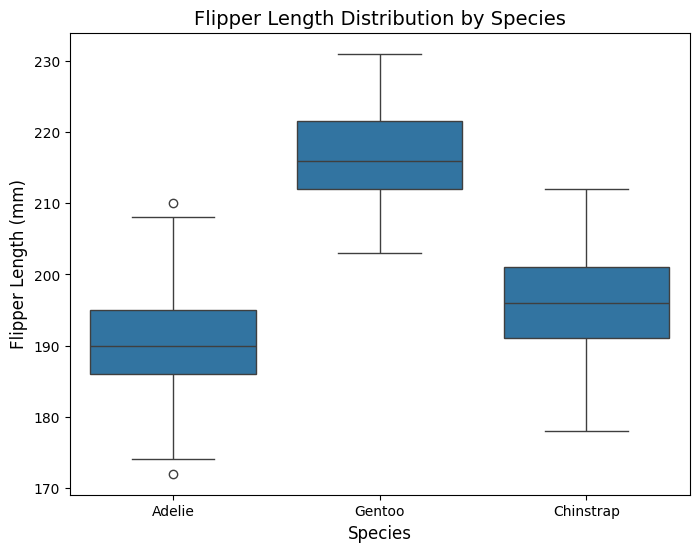

In [19]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=penguins_clean, 
    x='species', 
    y='flipper_length_mm'
)

plt.title("Flipper Length Distribution by Species", fontsize=14)
plt.xlabel("Species", fontsize=12)
plt.ylabel("Flipper Length (mm)", fontsize=12)
plt.show()

The Gentoo penguins have the highest median flipper length and are completely seperated from the other two species. Their IQR's do not overlap with Gentoo's. Adelie and Chinstrap penguins have much closer median flipper lengths, and their overall spread is very similar, but Chinstrap flippers tend to be slightly longer on average.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

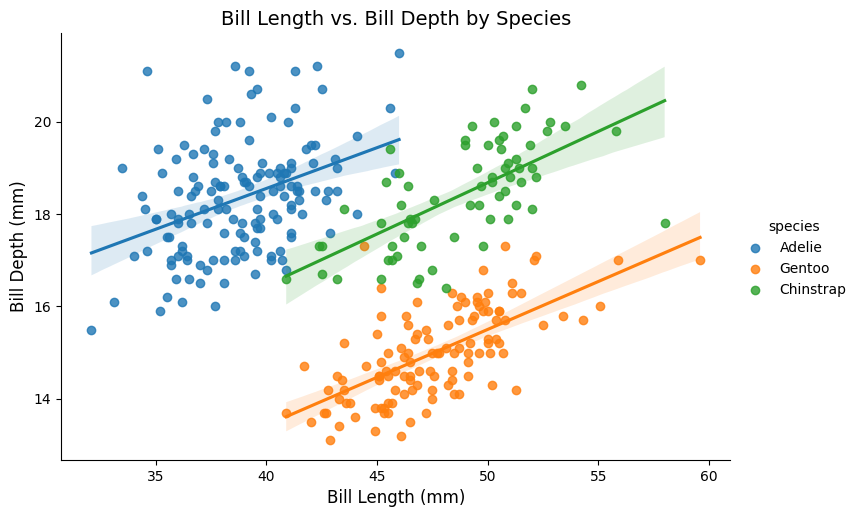

In [21]:
sns.lmplot(
    data=penguins_clean,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species', 
    aspect = 1.5
)

plt.title("Bill Length vs. Bill Depth by Species", fontsize=14)
plt.xlabel("Bill Length (mm)", fontsize=12)
plt.ylabel("Bill Depth (mm)", fontsize=12)
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

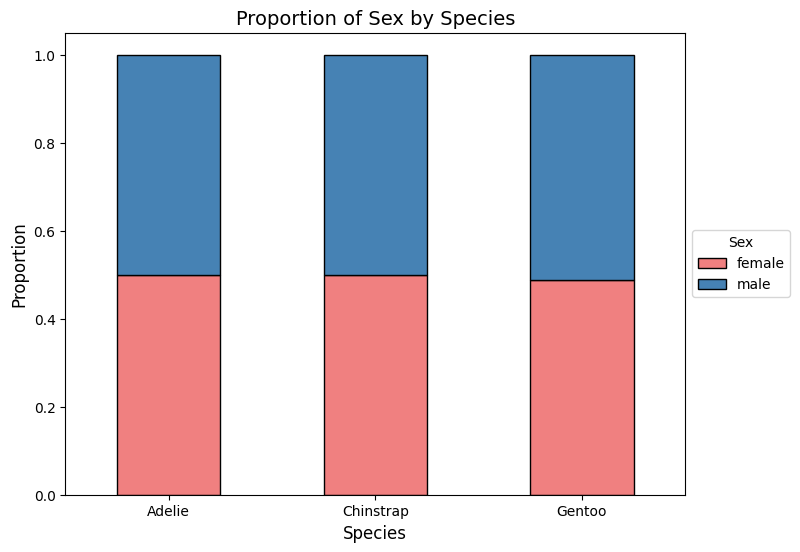

In [23]:
# counts of each sex within each species and reshape it
species_sex_counts = penguins_clean.groupby(['species', 'sex']).size().unstack()

# Convert counts to proportions 
species_sex_props = species_sex_counts.div(species_sex_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
species_sex_props.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=['lightcoral', 'steelblue'], 
    edgecolor='black'
)

ax.set_title('Proportion of Sex by Species', fontsize=14)
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0) 
ax.legend(title='Sex', loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()